/home/ebertp/work/projects/chrom-y-extended
/home/ebertp/work/cloud/sciebo/share/outgoing/projects/project-chrom-y-extended/plots/region-overlap-stats
t2tv2
['UNASSIGNED', 'PAR1', 'XDR1', 'XTR1', 'AMPL1', 'XTR2', 'XDR2', 'AMPL2', 'periCEN', 'CEN-DYZ3', 'XDR3', 'AMPL3', 'XDR4', 'AMPL4', 'XDR5', 'AMPL5', 'XDR6', 'AMPL6', 'XDR7', 'DYZ19', 'XDR8', 'AMPL7', 'OTHER', 'HET', 'PAR2']
hg38
['UNASSIGNED', 'PAR1', 'XDR1', 'XTR1', 'AMPL1_IR3d', 'XTR2', 'XDR2', 'AMPL2', 'other1', 'periCEN', 'CEN-DYZ3', 'XDR3', 'AMPL3', 'XDR4', 'AMPL4', 'XDR5', 'AMPL5', 'XDR6', 'AMPL6', 'XDR7', 'DYZ19', 'XDR8', 'AMPL7', 'other2', 'HET', 'PAR2']


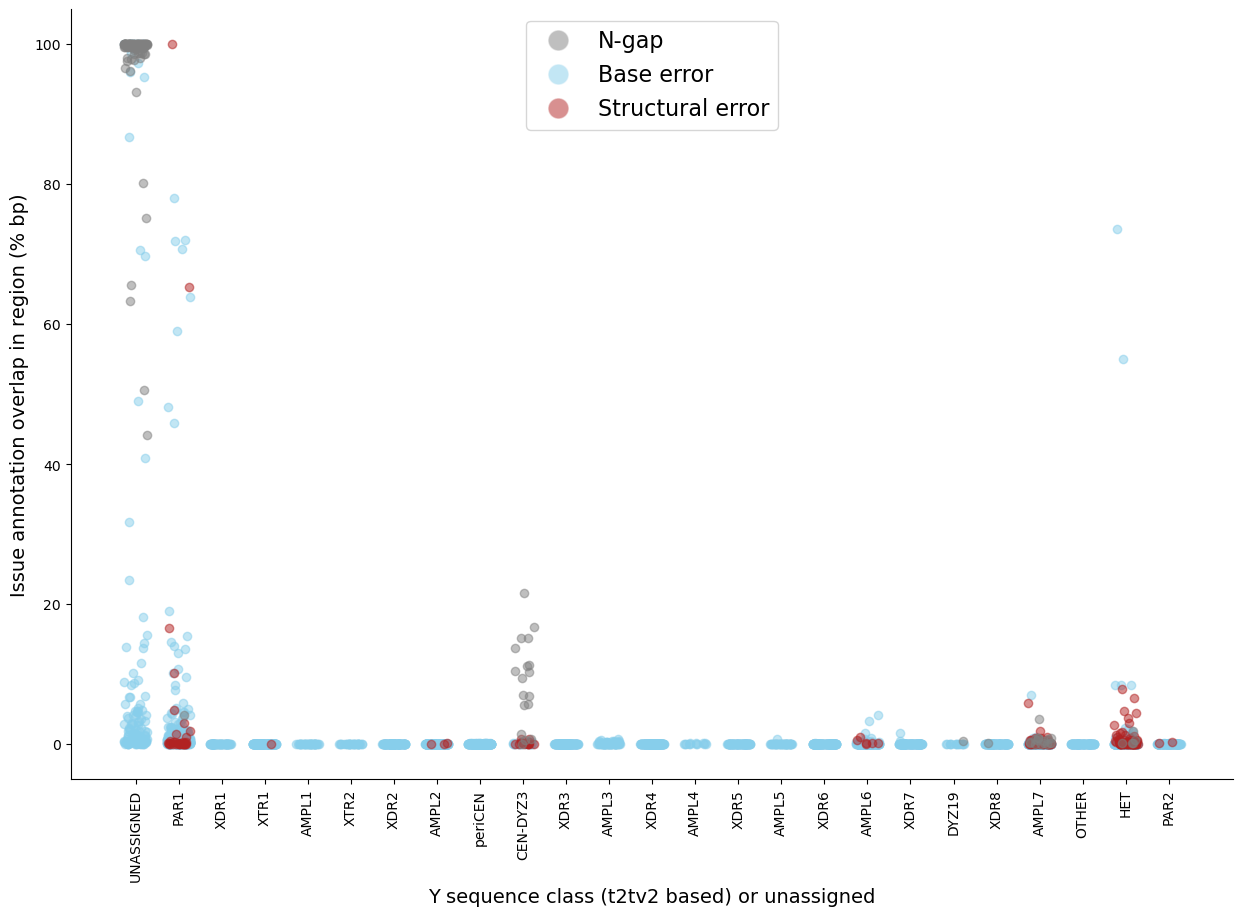

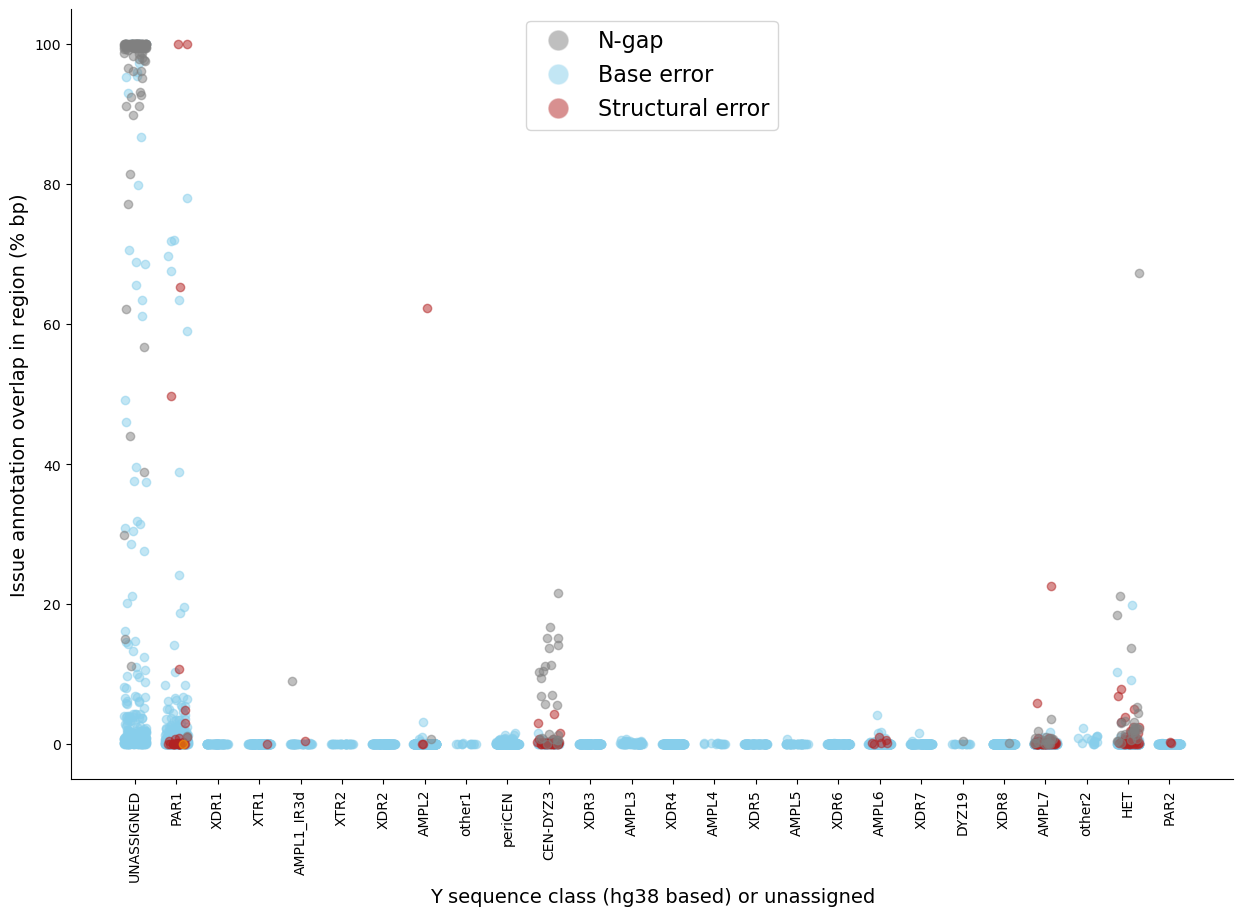

In [49]:
import pathlib as pl

# adapt relative path until it loads
cfg_nb = pl.Path("../../../load-config.ipynb").resolve(strict=True)
%run $cfg_nb

_NB_SESSION = __session__
NB_NAME = pl.Path(_NB_SESSION).name
NB_PATH = pl.Path(_NB_SESSION).parent
NB_REL_PATH = NB_PATH.relative_to(CONFIG["project_repo"]).joinpath(NB_NAME)

PLOT_ROOT = CONFIG["plot_root"].joinpath(NB_PATH.stem)
TABLE_ROOT = CONFIG["table_root"].joinpath(NB_PATH.stem)
NB_CACHE_FOLDER = CONFIG["nb_cache_folder"]
DATA_ROOT = CONFIG["project_data"]

import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

print(DATA_ROOT)
print(PLOT_ROOT)

# actual NB code

import collections as col
import dataclasses as dcl
import pandas as pd
import functools as fnt
import json
import re
import itertools as itt
import numpy.random as rng
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mplcol
import matplotlib.lines as mpllin

ref_base_path = pl.Path("/home/ebertp/work/code/cubi/project-chrom-y-extended/annotation/norm")

ref_files = {
    "t2tv2": "HG002-Y_T2Tv2_regions_repeat-details.bed",
    "hg38": "GRCh38-Y_regions_repeat-details.bed"
}
ref_hg = {
    "t2tv2": "J1",
    "hg38": "R1"
}

DATA_FOLDER = DATA_ROOT.joinpath("wf-data", "region-labels", "label_stats")

UMBRELLA_LABEL_ROOT = DATA_ROOT.joinpath(
    "wf-data/region-labels/umbrellas"
)

@dcl.dataclass
class IssueColors:
    NGAP = mplcol.to_rgba("grey", alpha=0.5)
    ERRSTRUCT = mplcol.to_rgba("firebrick", alpha=0.5)
    ERRBASE = mplcol.to_rgba("skyblue", alpha=0.5)
    UNASSIGNED = mplcol.to_rgba("orange", alpha=0.5)
    
    def get_color_labels(self):
        labels = [
            "unassigned",
            "N-gap",
            "Base error",
            "Structural error",
        ]
        return labels

    def get_issue_labels(self):
        labels = [
            "UNASSIGNED",
            "NGAP",
            "ERRBASE",
            "ERRSTRUCT"
        ]
        return labels


ISSUE_COLORS = IssueColors()
ISSUE_LABELS = ISSUE_COLORS.get_issue_labels()


def load_umbrella_file(fp):

    with open(fp, "r") as dump:
        umbrella_lut = json.load(dump)
    return umbrella_lut


def relabel_to_unified(row, sample_labels, col_name):
    # super annoying: index name is 'Name'
    # by default, and accessing row.name
    # returns the index value (= the row number)
    try:
        new_label = sample_labels[row[col_name]]["unified"]
        if new_label == "PAR1,PAR2":
            if row.start < int(2.5e6):
                new_label = "PAR1"
            else:
                new_label = "PAR2"
        assert "," not in new_label
    except KeyError:
        if row[col_name] in ISSUE_LABELS:
            new_label = row[col_name]
        else:
            new_label = "notumbrella"
    return new_label


for ref, ref_file in ref_files.items():
    print(ref)

    ref_umbrella_file = sorted(UMBRELLA_LABEL_ROOT.joinpath(f"{ref}").glob(f"{ref}*.json"))[0]
    assert ref_umbrella_file.name.startswith(ref)
    umbrella_labels = load_umbrella_file(ref_umbrella_file)

    ref_labels = ["UNASSIGNED"]
    for key in sorted(umbrella_labels.keys()):
        unified_label = umbrella_labels[key]["unified"]
        if unified_label in ref_labels:
            continue
        ref_labels.append(unified_label)
    print(ref_labels)
    
    data_table_file = DATA_FOLDER.joinpath(f"{ref}.final-draft-ovl-stats.tsv")
    data_table = pd.read_csv(data_table_file, sep="\t", header=0)

    sample_umbrella_file = sorted(UMBRELLA_LABEL_ROOT.joinpath(f"{ref}").glob(f"*{ref}*.json"))[0]
    assert not sample_umbrella_file.name.startswith(ref)
    sample_labels = load_umbrella_file(sample_umbrella_file)
    
    # consider only main seqs
    data_table = data_table.loc[data_table["seq_type"] == "main", :].copy()

    # relabel to unified label
    data_table["name"] = data_table.apply(relabel_to_unified, args=(sample_labels, "name"), axis=1)
    data_table["name2"] = data_table.apply(relabel_to_unified, args=(sample_labels, "name2"), axis=1)
    # drop id/self ovl.
    data_table = data_table.loc[data_table["name"] != data_table["name2"], :].copy()
    # drop non-umbrella / non-issue
    deselect = (data_table["name"] != "notumbrella") & (data_table["name2"] != "notumbrella")
    data_table = data_table.loc[deselect, :].copy()
    # ignore errors in name column
    data_table = data_table.loc[data_table["name"].isin(ref_labels), :].copy()
    # only check issue categories
    data_table = data_table.loc[data_table["name2"].isin(ISSUE_LABELS), :].copy()
    
    plot_data = data_table.groupby(["name", "name2"])["overlap_pct"].apply(list)

    fig, ax = plt.subplots(figsize=(15,10))
    x_labels = []
    for idx_pos, label in enumerate(ref_labels, start=0):
        x_labels.append(label)
        try:
            sub = plot_data.xs(label, level="name")
        except KeyError:
            continue

        for other, y_values in sub.items():
            color = getattr(ISSUE_COLORS, other)
            x_values = rng.uniform(idx_pos-0.275, idx_pos+0.275, size=len(y_values))
            ax.scatter(x_values, y_values, color=color)

    x_ticks = np.arange(0, len(ref_labels))
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, rotation=90)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlabel(f"Y sequence class ({ref} based) or unassigned", fontsize=14)
    ax.set_ylabel("Issue annotation overlap in region (% bp)", fontsize=14)

    legend_elements = []
    
    for other, legend_label in zip(ISSUE_LABELS, ISSUE_COLORS.get_color_labels()):
        if other == "UNASSIGNED":
            continue
        color = getattr(ISSUE_COLORS, other)
        elem = mpllin.Line2D(
            [], [], color="white",
            markerfacecolor=color, markersize=15,
            marker="o", label=legend_label
        )
        legend_elements.append(elem)
    ax.legend(handles=legend_elements, loc='upper center', fontsize=16)

    out_file = PLOT_ROOT.joinpath("issue-by-group", f"supp_issues-pct-cov-by-region.pe.{ref}.png")
    out_file.parent.mkdir(exist_ok=True, parents=True)
    plt.savefig(out_file, bbox_inches="tight", dpi=150, transparent=None, facecolor="w")
    out_file = out_file.with_suffix(".pdf")
    plt.savefig(out_file, bbox_inches="tight", transparent=None, facecolor="w")
    